In [1]:
import pickle, glob
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_episode(path):
    with open(path, "rb") as fh:
        return pickle.load(fh)

stacking ep 1 successful= False steps= 100


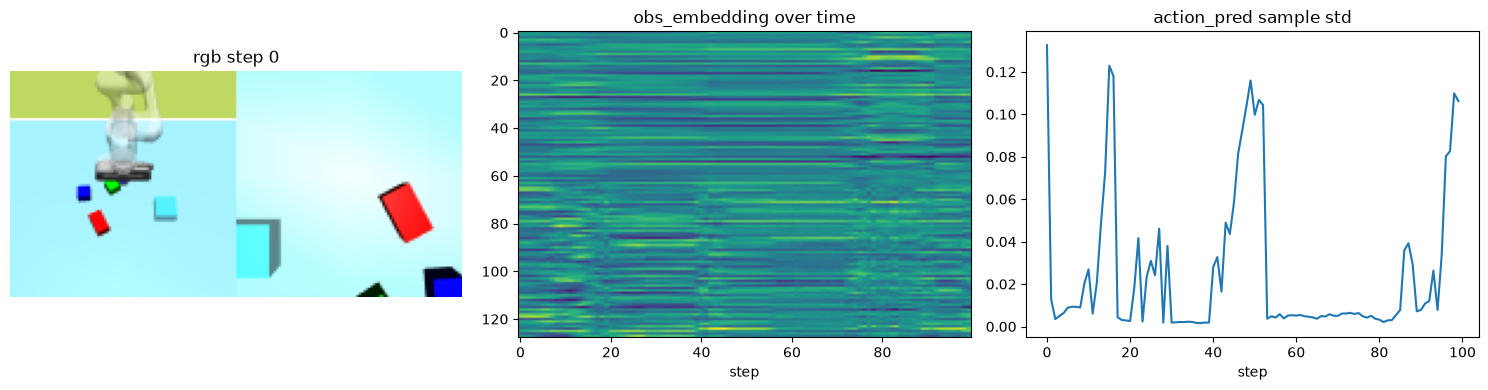

In [3]:
ep   = load_episode(sorted(glob.glob("../data/stacking/rollouts/test/episode_f_*.pkl"))[0])
meta = ep["metadata"]
roll = ep["rollout"]
print(meta["task"], "ep", meta["episode"], "successful=", meta["successful"], "steps=", len(roll))

# take last 128 dims so every step's obs_embedding is comparable
obs  = np.stack([s["obs_embedding"][-128:] for s in roll])   # (T, 128)
pred = np.stack([s["action_pred"]          for s in roll])   # (T, 32, 8, 21)
ace  = pred.std(axis=1).mean(axis=(1, 2))                    # (T,) sample disagreement ~ ACE proxy

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(roll[0]["rgb"]);                 ax[0].set_title("rgb step 0"); ax[0].axis("off")
ax[1].imshow(obs.T, aspect="auto");           ax[1].set_title("obs_embedding over time"); ax[1].set_xlabel("step")
ax[2].plot(ace);                              ax[2].set_title("action_pred sample std"); ax[2].set_xlabel("step")
plt.tight_layout()
plt.show()

apred: T, B, H, dim

In [4]:
def extract_ee_positions(ep):
    """(T, 32, 8, 3) array of EE xyz over every sampled action chunk in an episode."""
    pos = ep["metadata"]["action_mappings"]["pos"]   # [0, 1, 2]
    preds = np.stack([s["action_pred"] for s in ep["rollout"]])  # (T, 32, 8, 21)
    return preds[..., pos]                                        # (T, 32, 8, 3)

In [5]:
am = ep["metadata"]["action_mappings"]
idx = am["joint_pos"] + am["gripper"]

In [6]:
roll[0].keys()

dict_keys(['rgb', 'action', 'action_pred', 'agent_pos', 'obs_embedding', 'state_embedding', 'timestamp', 'step'])

In [7]:
chunk = extract_ee_positions(ep)

In [ ]:
def plot_chunk_samples(chunk, t, ax=None):
    """3D fan-out: the 32 sampled 8-step EE trajectories predicted at step t."""
    chunks = chunk[t]                                   # (32, 8, 3)
    ax = ax or plt.figure(figsize=(6, 5)).add_subplot(111, projection="3d")
    for c in chunks:                                  # each (8, 3)
        ax.plot(c[:, 0], c[:, 1], c[:, 2], lw=0.6, alpha=0.4, color="tab:blue")
    ax.scatter(*chunks[:, -1].T, s=8, color="tab:red", label="endpoints")  # what ACE bins
    ax.set(xlabel="x", ylabel="y", zlabel="z", title=f"step {t}: 32 predicted chunks")
    return ax


<Axes3D: title={'center': 'step 70: 32 predicted chunks'}, xlabel='x', ylabel='y', zlabel='z'>

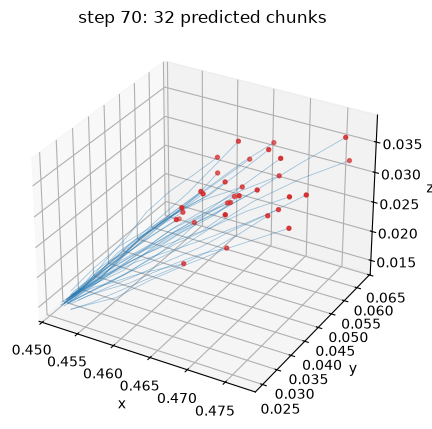

In [25]:
plot_chunk_samples(chunk, t=70)

<Axes: title={'center': 'EE-position dispersion per step'}, xlabel='step', ylabel='sample std'>

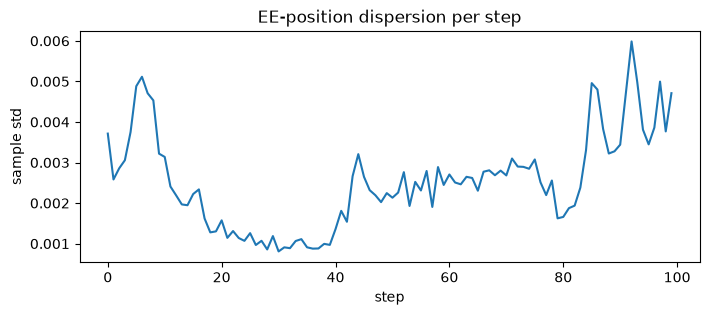

In [52]:
def plot_dispersion(chunk, ax=None):
    """ACE proxy over time: std across the 32 samples, averaged over horizon & xyz."""
    disp = chunk.std(axis=1).mean(axis=(1, 2))          # (T,)
    ax = ax or plt.subplots(figsize=(8, 3))[1]
    ax.plot(disp)
    ax.set(xlabel="step", ylabel="sample std", title="EE-position dispersion per step")
    return ax

plot_dispersion(chunk)

In [31]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

def plot_chunks_over_time(pos, stride=5, steps=None, n_samples=None, cmap="viridis", ax=None):
    """All 32-sample chunks across the episode in one 3D plot, colored by step."""
    T = pos.shape[0]
    steps = steps if steps is not None else range(0, T, stride)
    norm = Normalize(0, T - 1)
    cm = plt.get_cmap(cmap)
    ax = ax or plt.figure(figsize=(7, 6)).add_subplot(111, projection="3d")

    for t in steps:
        chunks = pos[t]                                  # (32, 8, 3)
        if n_samples:                                    # thin samples to cut clutter
            chunks = chunks[:n_samples]
        color = cm(norm(t))
        for c in chunks:
            ax.plot(c[:, 0], c[:, 1], c[:, 2], lw=0.5, alpha=0.25, color=color)

    ax.set(xlabel="x", ylabel="y", zlabel="z", title="predicted chunks over time")
    plt.colorbar(ScalarMappable(norm=norm, cmap=cm), ax=ax, label="step", shrink=0.6)
    return ax

<Axes3D: title={'center': 'predicted chunks over time'}, xlabel='x', ylabel='y', zlabel='z'>

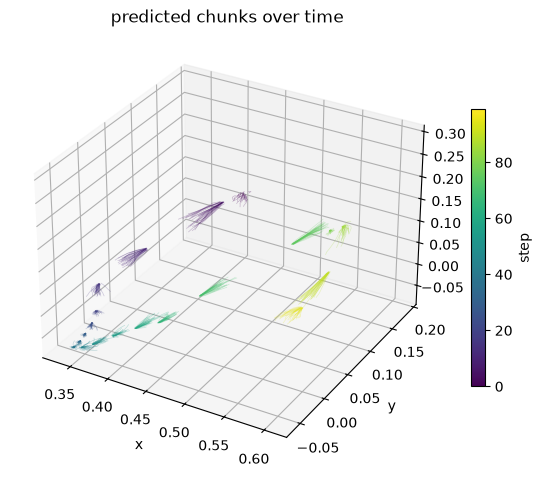

In [32]:
plot_chunks_over_time(chunk)

In [39]:
import plotly.graph_objects as go
from plotly.colors import sample_colorscale

def plot_chunks_over_time_plotly(pos, stride=5, steps=None, n_samples=None, colorscale="Viridis"):
    """Interactive 3D: all 32-sample chunks across the episode, colored by step."""
    T = pos.shape[0]
    steps = list(steps) if steps is not None else list(range(0, T, stride))
    colors = sample_colorscale(colorscale, [t / max(T - 1, 1) for t in steps])

    fig = go.Figure()
    for t, color in zip(steps, colors):
        chunks = pos[t]                                   # (32, 8, 3)
        if n_samples:
            chunks = chunks[:n_samples]
        # stitch all sample-chunks into one trace, separated by NaN breaks (fast: 1 trace/step)
        nan = np.full((chunks.shape[0], 1, 3), np.nan)
        xyz = np.concatenate([chunks, nan], axis=1).reshape(-1, 3)
        fig.add_trace(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode="lines", line=dict(color=color, width=2),
            opacity=0.4, name=f"step {t}", legendgroup=f"{t}", showlegend=False))

    # executed path: sample 0 is the committed chunk; its first horizon point per step is the realized route
    exec_path = pos[:, 0, 0, :]                           # (T, 3)
    fig.add_trace(go.Scatter3d(
        x=exec_path[:, 0], y=exec_path[:, 1], z=exec_path[:, 2],
        mode="lines", line=dict(color="black", width=2, dash="dot"),
        opacity=0.45, name="executed"))

    # colorbar proxy for the step gradient
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None], mode="markers",
        marker=dict(color=[0, T - 1], colorscale=colorscale, cmin=0, cmax=T - 1,
                    colorbar=dict(title="step"), showscale=True), showlegend=False))

    # data-proportional axes so the EE-position spread reads truthfully
    fig.update_layout(scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z",
                                 aspectmode="data"),
                      title="predicted chunks over time", width=800, height=700)
    return fig


In [40]:
plot_chunks_over_time_plotly(chunk)